# 1 - Thu thập & Tiền xử lý dữ liệu

Notebook này phục vụ việc thu thập dữ liệu giá (OHLCV) từ `vnstock` hoặc `yfinance`, cũng như Crawl dữ liệu tin tức tài chính. Sau đó thực hiện làm sạch dữ liệu, thêm các chỉ báo kỹ thuật (RSI, MACD,...) và chia tập Train/Val/Test.

In [3]:
import sys
try:
    from google.colab import drive
    # Mount Drive
    drive.mount('/content/drive')
    # Thêm đường dẫn tới thư mục 04_Source_Code để Colab hiểu được các file .py của bạn
    PROJECT_PATH = '/content/drive/MyDrive/DeTaiHocSauKetHopDoAnTongHop/Stock_Forecasting_Project'
    sys.path.append(f'{PROJECT_PATH}/04_Source_Code')
except ImportError:
    print("Running locally, skipping Colab mount")


Running locally, skipping Colab mount


In [4]:
# 1. Cài đặt chính xác phiên bản ổn định bằng pip truyền thống
!pip install --force-reinstall vnstock==0.2.8



Error processing line 1 of C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\google_generativeai-0.8.6-py3.13-nspkg.pth:

Fatal Python error: init_import_site: Failed to import the site module
Python runtime state: initialized
Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\lib\site.py", line 206, in addpackage
    exec(line)
  File "<string>", line 1, in <module>
  File "C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\lib\importlib\machinery.py", line 15, in <module>
    from ._bootstrap_external import NamespaceLoader
ImportError: cannot import name 'NamespaceLoader' from 'importlib._bootstrap_external' (C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\lib\importlib\_bootstrap_external.py)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12-

In [5]:
import os
from datetime import datetime
import pandas as pd
import pandas_ta as ta
from vnstock import stock_historical_data

# --- CẤU HÌNH ĐƯỜNG DẪN ĐỒ ÁN (PERSISTENCE) ---
# Tự động ưu tiên đường dẫn Google Drive nếu tìm thấy, nếu không sẽ lưu cục bộ (.)
DRIVE_PATH = '/content/drive/MyDrive/DeTaiHocSauKetHopDoAnTongHop/Stock_Forecasting_Project'
PROJECT_PATH = DRIVE_PATH if os.path.exists(DRIVE_PATH) else '.'

TICKER = "FPT"
START_DATE = "2021-01-01"
END_DATE = datetime.now().strftime("%Y-%m-%d") # Volatility Check: Luôn lấy ngày mới nhất

def fetch_and_process_stock_data(symbol: str, start: str, end: str) -> pd.DataFrame:
    """Thu thập dữ liệu lịch sử và trích xuất đặc trưng kỹ thuật."""
    print(f"Đang tải dữ liệu lịch sử mã {symbol} từ {start} đến {end}...")
    df = stock_historical_data(symbol=symbol, start_date=start, end_date=end, resolution='1D', type='stock')

    if df.empty:
        raise ValueError("Không nhận được dữ liệu từ vnstock.")

    # Chuẩn hóa Index thời gian
    df.set_index('time', inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df[~df.index.duplicated(keep='first')]
    df.columns = [col.lower() for col in df.columns]

    print("Đang tính toán các chỉ báo kỹ thuật AI...")
    df.ta.rsi(length=14, append=True)
    df.ta.macd(append=True)
    df.ta.bbands(append=True)

    return df

def generate_three_class_labels(df: pd.DataFrame, threshold: float = 0.005) -> pd.DataFrame:
    """
    Gán nhãn xu hướng giá cho ngày mai dựa trên biên độ thay đổi (Mục 1.4.1 của Đề cương).
    1 : Tăng (delta > 0.5%)
    0 : Đi ngang (-0.5% <= delta <= 0.5%)
    -1: Giảm (delta < -0.5%)
    """
    print("Đang tiến hành gán nhãn xu hướng 3 phân lớp...")
    # Tính toán tỷ lệ thay đổi giá đóng cửa của ngày mai so với hôm nay
    df['next_close'] = df['close'].shift(-1)
    df['pct_change'] = (df['next_close'] - df['close']) / df['close']

    # Logic gán nhãn đa lớp
    df['target'] = 0  # Mặc định là đi ngang
    df.loc[df['pct_change'] > threshold, 'target'] = 1
    df.loc[df['pct_change'] < -threshold, 'target'] = -1

    # Xóa các cột phụ trợ và xóa hàng cuối cùng (vì ngày cuối không có ngày mai để dự báo)
    df.drop(columns=['next_close', 'pct_change'], inplace=True)
    df.dropna(inplace=True)
    return df

def mock_financial_news_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """Hàm giả lập điểm cảm xúc văn bản để tích hợp NLP vào đồ án sau này."""
    print("Đang thiết lập Pipeline dữ liệu văn bản tài chính...")
    # Tạo ngẫu nhiên điểm sentiment từ -1 đến 1 để làm khung dữ liệu mẫu cho File 2
    import numpy as np
    df['sentiment_score'] = np.random.uniform(-0.2, 0.2, size=len(df))
    return df

def save_processed_data(df: pd.DataFrame, base_path: str) -> None:
    """Lưu trữ dữ liệu vào thư mục quy định."""
    output_dir = os.path.join(base_path, "01_Data")
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, "processed_data.csv")
    df.to_csv(file_path)
    print(f"✅ THÀNH CÔNG! Đã lưu file dữ liệu sạch cho đồ án tại: {file_path}")

# --- LUỒNG CHẠY CHÍNH ---
if __name__ == "__main__":
    try:
        raw_df = fetch_and_process_stock_data(TICKER, START_DATE, END_DATE)
        labeled_df = generate_three_class_labels(raw_df, threshold=0.005)
        processed_df = mock_financial_news_pipeline(labeled_df)

        # Lưu file dữ liệu vào đúng cấu trúc thư mục
        save_processed_data(processed_df, PROJECT_PATH)
        print(processed_df[['close', 'target', 'sentiment_score']].tail())
    except Exception as e:
        print(f"❌ Sự cố vận hành: {e}")

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.4.

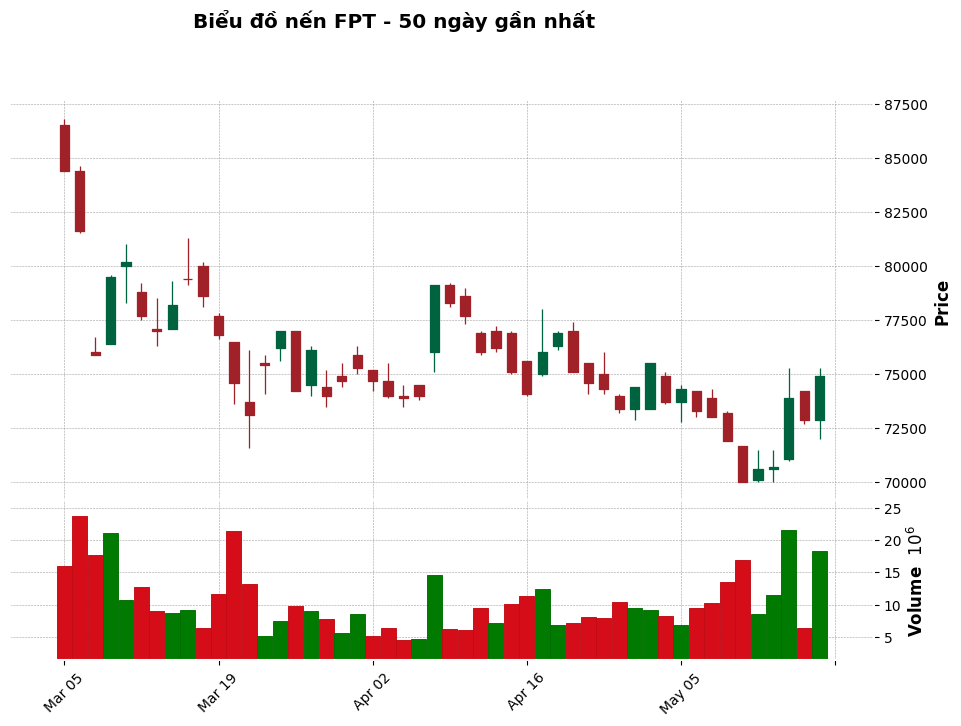

In [ ]:
import mplfinance as mpf
import pandas as pd

# Sử dụng dữ liệu đã processed từ ô lệnh phía trên
df_plot = processed_df.copy()

# 1. BƯỚC QUAN TRỌNG: Ép kiểu cột Index từ Chữ sang dạng Ngày tháng chuẩn
df_plot.index = pd.to_datetime(df_plot.index)

# 2. Đổi tên cột cho đúng chuẩn của thư viện vẽ hình (Viết hoa chữ cái đầu)
df_plot = df_plot.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

# 3. Lấy 50 ngày gần nhất để vẽ cho trực quan, không bị rối mắt
df_50_ngay = df_plot.tail(50)

# 4. Vẽ biểu đồ nến kèm khối lượng giao dịch
mpf.plot(
    df_50_ngay,
    type='candle',
    style='charles',
    title='Biểu đồ nến FPT - 50 ngày gần nhất',
    volume=True,
    figsize=(12, 8)
)